In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import pyodbc

In [3]:
#1. import database / data

In [4]:
print(pyodbc.drivers())

['SQL Server', 'ODBC Driver 17 for SQL Server', 'SQL Server Native Client RDA 11.0', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [5]:
conn = pyodbc.connect(
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=DESKTOP-TNJ1I9U;"
    "Database=Customer_Churn;"
    "Trusted_Connection=yes;"
)

In [6]:
tables = pd.read_sql(
    """
    SELECT TABLE_NAME
    FROM INFORMATION_SCHEMA.TABLES
    WHERE TABLE_TYPE = 'BASE TABLE'
    """,
    conn
)

for table in tables['TABLE_NAME']:
    globals()[f"df_{table}"] = pd.read_sql(f"SELECT * FROM {table}", conn)
    print(f"Created dataframe: df_{table}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [7]:
print(df_db_customer.columns)
print(df_db_subscription.columns)
print(df_db_support.columns)

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode'],
      dtype='object')
Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score'],
      dtype='object')
Index(['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1',
       'comment'],
      dtype='object')


In [8]:
#2. Data cleaning

In [9]:
# Table 1

df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,None


In [10]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06,None,None
21,None,None,None,None,None,None,None,None


In [11]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.5+ KB


In [12]:
#a. rename col - name

#b. drop columns - intrests and pincode

#c. change data type - dob

#d. data standardization - gender

#d. fix missing values - country

In [13]:
#a. rename col - name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)
df_db_customer.head(3)

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,None


In [14]:
#b. drop columns - interests and pincode

df_db_customer.drop(columns = ['interests','pincode'],  inplace = True)
df_db_customer.head(3)

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15


In [15]:
#c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [16]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.2+ KB


In [17]:
#d. data standardization - gender

df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men', None], dtype=object)

In [18]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [19]:
df_db_customer['gender'].unique()

array(['Male', 'Female', None], dtype=object)

In [20]:
#d. fix missing values - country

df_db_customer.loc[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01
21,None,None,None,None,None,NaT


In [21]:
# country and state - unique value pair

state_country_mapping = df_db_customer.dropna(subset = 'country').set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [22]:
df_db_customer.loc[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
21,None,None,NaN,None,None,NaT


In [23]:
df_db_customer.dropna(how ='all', inplace = True)

In [24]:
df_db_customer.tail(4)

,customerid,customer_name,country,state,gender,dob
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Male,1991-05-14
20,0023-UYUPN,sudevi,India,Maharashtra,Female,1977-10-06


In [25]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        21 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [26]:
# Table 2

In [27]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34


In [28]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [29]:
dates = ['subscription_start_date','renewal_date', 'cancellation_date']

df_db_subscription[dates] = df_db_subscription[dates].apply(pd.to_datetime)   
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [30]:
# Table 3

In [31]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,False,60,None,service issue
1,0003-MKNFE,2024-08-28,True,10,None,demaned refund
2,0013-EXCHZ,2024-01-20,True,20,None,None
3,0013-MHZWF,2025-03-18,False,90,None,guidance to renew
4,0013-SMEOE,2024-11-01,False,30,None,None


In [32]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      bool  
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: bool(1), int64(1), object(4)
memory usage: 501.0+ bytes


In [33]:
# drop columns col_1 and comment

df_db_support.drop(columns = ['col_1','comment'], inplace = True)

In [34]:
df_db_support.head(3)

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,False,60
1,0003-MKNFE,2024-08-28,True,10
2,0013-EXCHZ,2024-01-20,True,20


In [35]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [36]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      bool          
 3   csat_score      9 non-null      int64         
dtypes: bool(1), datetime64[ns](1), int64(1), object(1)
memory usage: 357.0+ bytes


In [37]:
#3. Feature Engineering and Data Analysis:

In [38]:
# Creating new column using existing column - churn flag

df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34


In [39]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [40]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0


In [41]:
# merging all tables together for further analysis

df = (df_db_subscription
                    .merge(df_db_customer, on = 'customerid', how = 'left')
                    .merge(df_db_support, on = 'customerid', how = 'left'))

In [42]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,False,60.0


In [43]:
df.shape

(23, 20)

In [44]:
df_db_subscription.shape

(21, 12)

In [45]:
df_db_customer.shape

(21, 6)

In [46]:
df_db_support.shape

(9, 4)

In [47]:
df_db_support['customerid'].size

9

In [48]:
df_db_support['customerid'].nunique()

7

In [49]:
# the size of the table increased after joining, found 2 duplicates in support table - remove them and merge

df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,False,60
1,0003-MKNFE,2024-08-28,True,10
2,0013-EXCHZ,2024-01-20,True,20
3,0013-MHZWF,2025-03-18,False,90
4,0013-SMEOE,2024-11-01,False,30


In [50]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score
4,0013-SMEOE,2024-11-01,False,30
5,0017-IUDMW,2024-04-10,True,25
6,0019-EFAEP,2024-09-27,True,30
7,0022-TCJCI,2024-09-13,True,10
8,0022-TCJCI,2024-09-14,False,90


In [51]:
df_db_support['complain_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last', ignore_index = True)

In [52]:
df_db_support.shape

(7, 5)

In [53]:
# merging all tables together after removing duplicates

df = (df_db_subscription
                    .merge(df_db_customer, on = 'customerid', how = 'left')
                    .merge(df_db_support, on = 'customerid', how = 'left'))

In [54]:
df.shape

(21, 21)

In [55]:
df.to_csv('exported_churn_data.csv', index = False)

In [56]:
# Data Analysis:

In [57]:
#1. Churn rate:

In [58]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count'],
      dtype='object')

In [59]:
df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,True,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN


In [60]:
#1. Churn Rate

churn_rate = df['churn_flag'].mean()*100
print("Churn Rate : ",round(churn_rate,2),'%')

Churn Rate :  28.57 %


In [61]:
#2. Retention Rate

retention_rate = 100 - churn_rate
print("Retention Rate : ",round(retention_rate,2),'%')

Retention Rate :  71.43 %


In [62]:
#3. Churn by Plan Type

churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
churn_by_plan

,plan_type,churn_rate_pct
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [63]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,True,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,True,20.0,1.0


In [64]:
#4.a Churn by state + sum(revenue) and count of users

state_summary = df.groupby('state').agg(
    churn_rate_pct = ('churn_flag', lambda x: round(x.mean()*100,2)),
    total_revenue = ('monthly_charges',lambda x: round(x.sum(),2)),
    customer_count = ('customerid','count')
)
state_summary

,churn_rate_pct,total_revenue,customer_count
state,,,
Delhi,25.00,52.96,4
Karnataka,100.00,20.98,2
Kathmandu,0.00,20.98,2
Maharashtra,0.00,50.97,3
Meghalaya,66.67,42.97,3
Nagaland,0.00,22.99,1
Rajasthan,0.00,36.98,2
Telangana,50.00,30.98,2
Uttar Pradesh,0.00,115.98,2


In [65]:
#4.b Churn by subscription type + sum(revenue) and count of users

subscription_summary = df.groupby('subscription_type').agg(
    churn_rate_pct = ('churn_flag', lambda x: round(x.mean()*100,2)),
    total_revenue = ('monthly_charges',lambda x: round(x.sum(),2)),
    customer_count = ('customerid','nunique')
)
state_summary

subscription_summary

,churn_rate_pct,total_revenue,customer_count
subscription_type,,,
Organic,0.00,145.91,9
Paid,16.67,174.94,6
Refferal,83.33,74.94,6


In [66]:
#4.c Churn by contract_type + sum(revenue) and count of users 

contarct_summary = df.groupby('state').agg(
    churn_rate_by_contract = ('churn_flag', lambda x: round(x.mean(),2)),
    total_revenue = ('monthly_charges', lambda x: round(x.sum(),2)),
    customer_count = ('customerid', 'nunique')
)
contarct_summary 

,churn_rate_by_contract,total_revenue,customer_count
state,,,
Delhi,0.25,52.96,4
Karnataka,1.00,20.98,2
Kathmandu,0.00,20.98,2
Maharashtra,0.00,50.97,3
Meghalaya,0.67,42.97,3
Nagaland,0.00,22.99,1
Rajasthan,0.00,36.98,2
Telangana,0.50,30.98,2
Uttar Pradesh,0.00,115.98,2


In [67]:
#5. ARPU - Average revenue per user

ARPU = df['monthly_charges'].mean().round(2)
ARPU

np.float64(18.85)

In [68]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,True,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,True,20.0,1.0


In [69]:
#6. Average Customer Tenure
# Count of days users has used our services : cancellation date else current date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),
        
        (df['cancellation_date'] - df['subscription_start_date']).dt.days,
                             
        (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print('Avg Tenure (Days):',round(avg_tenure),0)

Avg Tenure (Days): 1499 0


In [70]:
#7. Revenue at Risk

revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum().round(2)
print('Revenue at Risk (Lakhs):',revenue_at_risk)

Revenue at Risk (Lakhs): 73.94


In [71]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days'],
      dtype='object')

In [72]:
df['escalations'].value_counts()

escalations
True     4
False    3
Name: count, dtype: int64

In [73]:
#8. Escalation Rate

esclation_rate = (df['escalations']==True).mean()*100
print('Esclation Rate:',round(esclation_rate,2),'%')

Esclation Rate: 19.05 %


In [74]:
#9. Avg complaint rate

avg_complaint_rate = df['complain_count'].sum() / df['customerid'].nunique()
print('Avg Complaint Rate:',round(avg_complaint_rate,2))

Avg Complaint Rate: 0.43


In [75]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,1954.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,True,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,1339.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,2629.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,True,20.0,1.0,419.0


In [76]:
#10. Correlation Escalation vs churn

df['escalations'] = np.where(df['escalations']==True, 1, 0)
corr_df = df[['escalations','churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print('Correlation between Escalation vs Churn:', round(correlation,2))

Correlation between Escalation vs Churn: 0.77


In [77]:
#11. Create a new col using exisiting col - Churn Risk 

conditions = [
            (df['churn_score'] < 50),
            (df['churn_score'] >= 50) & (df['churn_score'] < 70),
            (df['churn_score'] >= 70)
            ]

level = ['low','med', 'high'] 

df['churn_risk'] = np.select(conditions, level, default = 'unknown')

In [78]:
df[['churn_score','churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


In [79]:
#4. Visualization using Matplotlib

In [80]:
df_visual = df.copy()

In [81]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1954.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1339.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2629.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [82]:
df_visual['cancellation_date'] = pd.to_datetime(df_visual['cancellation_date'])

In [83]:
print(df_visual['cancellation_date'].dtype)

datetime64[ns]


In [84]:
df_visual['cancellation_date'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_date')['customerid'].count()

In [85]:
churn_trend

cancellation_date
2024-02    1
2024-05    1
2024-09    2
2024-10    1
2024-11    1
Freq: M, Name: customerid, dtype: int64

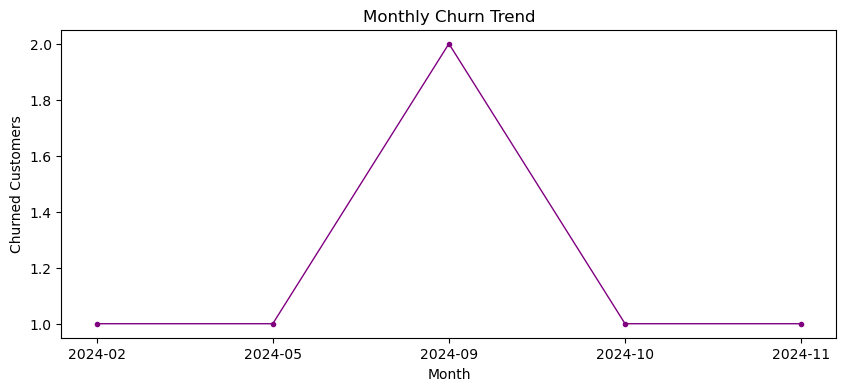

In [86]:
plt.figure(figsize = (10,4))

plt.plot(churn_trend.index.astype(str), churn_trend.values, color = 'purple', marker = 'o', markersize = 3, linewidth = 1)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')

plt.show()

In [87]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1954.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1339.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2629.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


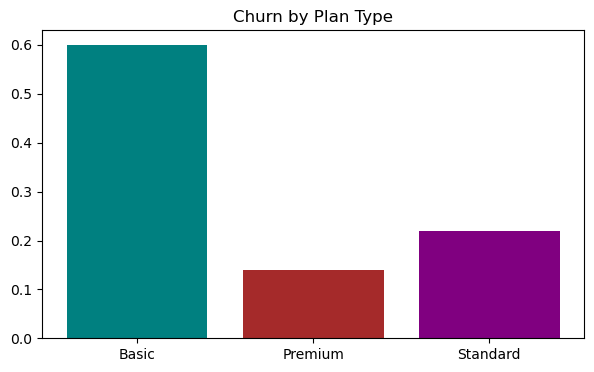

In [88]:
#4.2 Churn by plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean().round(2)

plt.figure(figsize=(7,4))
colors = ['teal','brown','purple']

plt.bar(churn_plan.index,churn_plan.values, color=colors)
plt.title('Churn by Plan Type')
plt.show()

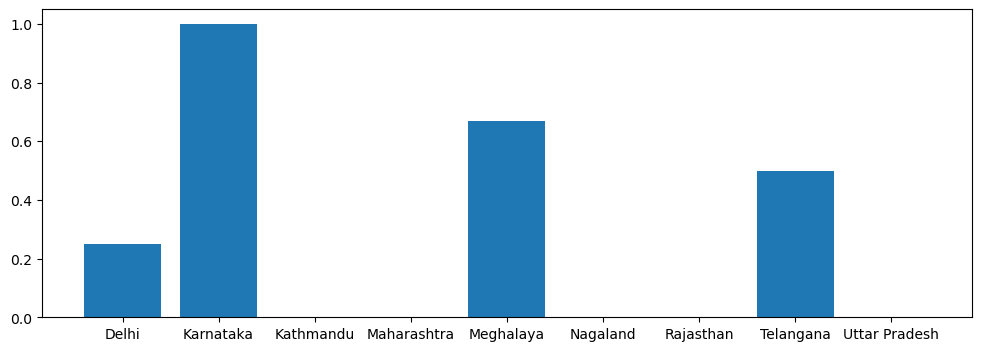

In [89]:
#4.3 Curn by state

churn_by_state = df_visual.groupby('state')['churn_flag'].mean().round(2)

plt.figure(figsize=(12,4))

plt.bar(churn_by_state.index, churn_by_state.values)
plt.show()

In [90]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [91]:
#4.4 Label encoding based on priority

df_encoded = df_visual[['plan_type', 'contract_type',  'churn_score',
       'churn_flag', 'escalations','churn_risk']]

order_mapping = {
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type' : ['Monthly','Annual'],
    'churn_risk' : ['low','med','high']
              } 

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered = True).codes

In [92]:
df_visual[['plan_type', 'contract_type',  'churn_score',
       'churn_flag', 'escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [93]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


<Axes: >

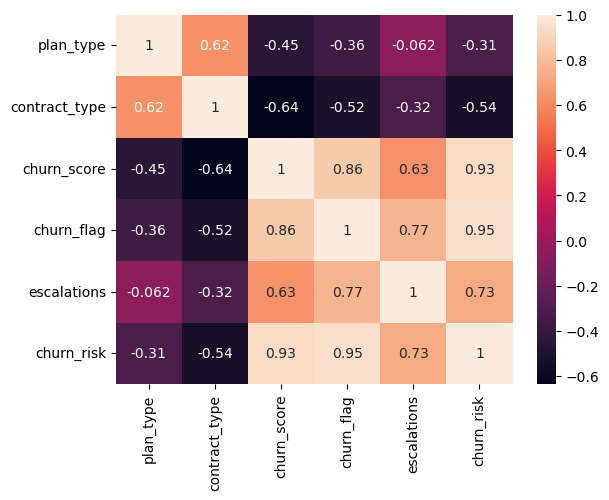

In [94]:
# Heatmap - Correlation matrix

sns.heatmap(df_encoded.corr(), annot = True)

In [96]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [99]:
# Pivot Table

pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['monthly_charges','customerid','churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.949999
Premium,0.142857,7,218.929996
Standard,0.222222,9,123.909998


In [ ]:
conn = pyodbc.connect(
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=DESKTOP-TNJ1I9U;"
    "Database=Test-database;"
    "Trusted_Connection=yes;"
)